Проверка и установка необходимых библиотек...
Библиотеки готовы.

Начало обработки видео...

--- Обработка файла: video_15s_480p.mp4 ---
Запуск: CUDA (Вариант 1: 2D Grid) ... Среднее: 0.00083 сек/кадр
Запуск: CUDA (Вариант 2: 3D Grid) ... Среднее: 0.00084 сек/кадр
Запуск: OpenCL (Вариант 1: 1D) ... 

/tmp/ipython-input-3445910316.py:123: RepeatedKernelRetrieval: Kernel 'process_1d' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  self.prg_cl.process_1d(self.queue_cl, global_size, local_size,


Среднее: 0.00139 сек/кадр
Запуск: OpenCL (Вариант 2: 2D Direct) ... 

/tmp/ipython-input-3445910316.py:132: RepeatedKernelRetrieval: Kernel 'process_2d_v1' has been retrieved more than once. Each retrieval creates a new, independent kernel, at possibly considerable expense. To avoid the expense, reuse the retrieved kernel instance. To avoid this warning, use cl.Kernel(prg, name).
  self.prg_cl.process_2d_v1(self.queue_cl, global_size, local_size,


Среднее: 0.00143 сек/кадр
Запуск: OpenCL (Вариант 3: 2D Transposed) ... 

...

Сохранен график: boxplot_CUDA_(Вариант_2_3D_Grid).png
Сохранен график: boxplot_OpenCL_(Вариант_1_1D).png


/tmp/ipython-input-3445910316.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=videos)
/tmp/ipython-input-3445910316.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=videos)


Сохранен график: boxplot_OpenCL_(Вариант_2_2D_Direct).png
Сохранен график: boxplot_OpenCL_(Вариант_3_2D_Transposed).png


/tmp/ipython-input-3445910316.py:206: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(plot_data, labels=videos)


<Figure size 1200x800 with 0 Axes>

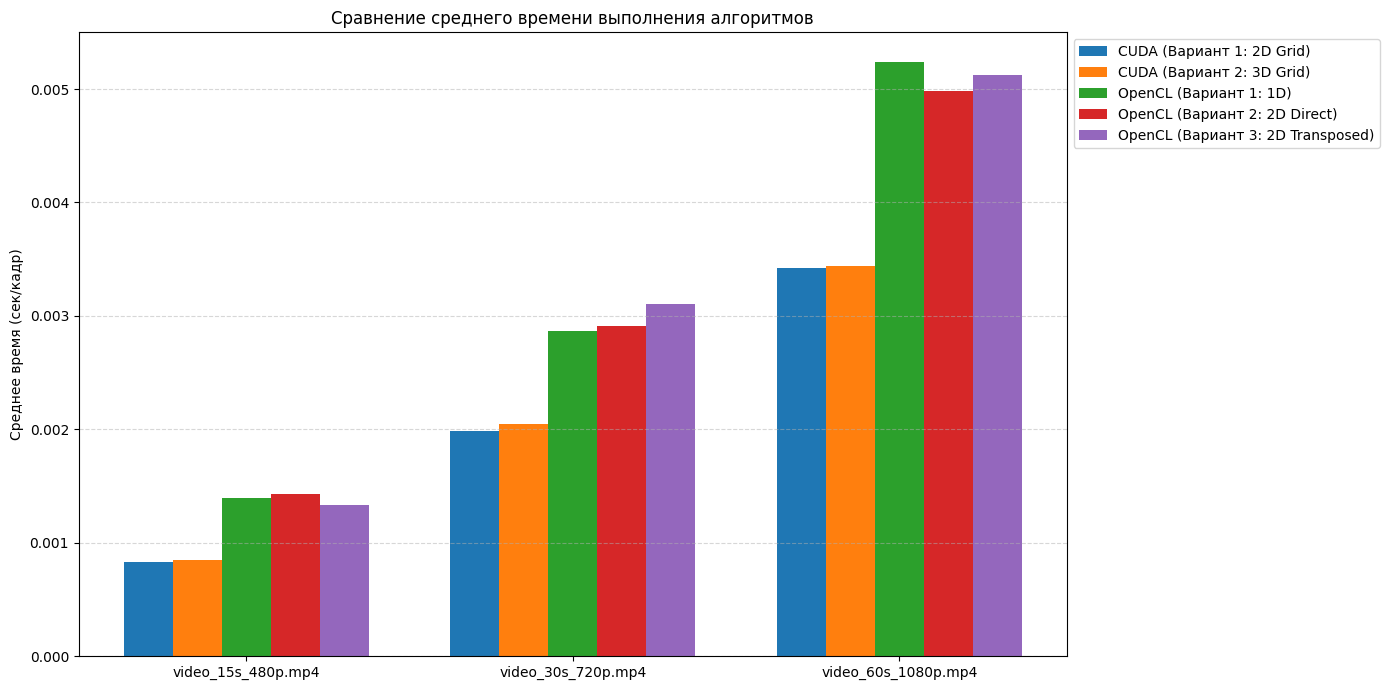

Сохранен график: average_performance_summary.png

>>> Работа завершена.


In [ ]:
import os
import sys
import time
import subprocess
import numpy as np
import cv2
import matplotlib.pyplot as plt

def install_requirements():
    print("Проверка и установка необходимых библиотек...")
    pkgs = ["pycuda", "pyopencl", "numpy", "opencv-python", "matplotlib"]
    for pkg in pkgs:
        try:
            __import__(pkg.split('-')[0] if pkg != "opencv-python" else "cv2")
        except ImportError:
            print(f"Установка {pkg}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    print("Библиотеки готовы.\n")

install_requirements()

import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import pyopencl as cl

class GPUProcessor:
    def __init__(self):
        self.mod_cuda = SourceModule(cuda_source)
        self.cuda_func_2d = self.mod_cuda.get_function("process_2d_grid")
        self.cuda_func_3d = self.mod_cuda.get_function("process_3d_grid")

        self.ctx_cl = cl.create_some_context(interactive=False)
        self.queue_cl = cl.CommandQueue(self.ctx_cl)
        self.prg_cl = cl.Program(self.ctx_cl, cl_source).build()

    def process_video(self, filename, method, variant):
        if not os.path.exists(filename):
            print(f"Ошибка: Файл {filename} не найден!")
            return []

        cap = cv2.VideoCapture(filename)
        width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        fps = cap.get(cv2.CAP_PROP_FPS)

        out_name = f"proc_{method}_{variant}_{filename}"
        out_writer = cv2.VideoWriter(out_name, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height), False)

        frame_times = []

        n_pixels = width * height

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            frame_flat = frame.astype(np.uint8).flatten()
            result_flat = np.zeros(n_pixels, dtype=np.uint8)

            start_time = time.time()

            if method == "CUDA":
                self._run_cuda(frame_flat, result_flat, width, height, variant)
            elif method == "OpenCL":
                self._run_opencl(frame_flat, result_flat, width, height, variant)

            end_time = time.time()

            frame_times.append(end_time - start_time)

            result_frame = result_flat.reshape((height, width))
            out_writer.write(result_frame)

        cap.release()
        out_writer.release()

        return frame_times

    def _run_cuda(self, host_in, host_out, w, h, variant):
        in_gpu = cuda.mem_alloc(host_in.nbytes)
        out_gpu = cuda.mem_alloc(host_out.nbytes)

        cuda.memcpy_htod(in_gpu, host_in)

        block_dim = (32, 32, 1)

        if variant == "2D_Grid":
            grid_x = (w + block_dim[0] - 1) // block_dim[0]
            grid_y = (h + block_dim[1] - 1) // block_dim[1]
            grid_dim = (grid_x, grid_y, 1)

            self.cuda_func_2d(out_gpu, in_gpu, np.int32(w), np.int32(h),
                              block=block_dim, grid=grid_dim)

        elif variant == "3D_Grid":
            grid_x = (w + block_dim[0] - 1) // block_dim[0]
            grid_y = (h + block_dim[1] - 1) // block_dim[1]
            grid_y_split = (grid_y + 1) // 2

            grid_dim = (grid_x, grid_y_split, 2)

            self.cuda_func_3d(out_gpu, in_gpu, np.int32(w), np.int32(h),
                              block=block_dim, grid=grid_dim)

        cuda.memcpy_dtoh(host_out, out_gpu)

        in_gpu.free()
        out_gpu.free()

    def _run_opencl(self, host_in, host_out, w, h, variant):
        mf = cl.mem_flags
        in_buf = cl.Buffer(self.ctx_cl, mf.READ_ONLY | mf.COPY_HOST_PTR, hostbuf=host_in)
        out_buf = cl.Buffer(self.ctx_cl, mf.WRITE_ONLY, size=host_out.nbytes)

        if variant == "1D":
            local_size = (256,)
            global_size = (w * h,)
            if global_size[0] % local_size[0] != 0:
                global_size = ((global_size[0] // local_size[0] + 1) * local_size[0],)

            self.prg_cl.process_1d(self.queue_cl, global_size, local_size,
                                   out_buf, in_buf, np.int32(w), np.int32(h))

        elif variant == "2D_V1":
            local_size = (16, 16)
            g_w = ((w + 15) // 16) * 16
            g_h = ((h + 15) // 16) * 16
            global_size = (g_w, g_h)

            self.prg_cl.process_2d_v1(self.queue_cl, global_size, local_size,
                                      out_buf, in_buf, np.int32(w), np.int32(h))

        elif variant == "2D_V2":
            local_size = (16, 16)
            g_h = ((h + 15) // 16) * 16
            g_w = ((w + 15) // 16) * 16
            global_size = (g_h, g_w)

            self.prg_cl.process_2d_v2(self.queue_cl, global_size, local_size,
                                      out_buf, in_buf, np.int32(w), np.int32(h))

        cl.enqueue_copy(self.queue_cl, host_out, out_buf)

def main():
    processor = GPUProcessor()

    videos = ["video_15s_480p.mp4", "video_30s_720p.mp4", "video_60s_1080p.mp4"]

    missing_files = [v for v in videos if not os.path.exists(v)]
    if missing_files:
        print(f"ОШИБКА: Отсутствуют следующие файлы видео: {missing_files}")
        print("Пожалуйста, загрузите файлы с именами video_15s.mp4, video_30s.mp4, video_60s.mp4 в среду Colab.")
        return

    tasks = [
        ("CUDA", "2D_Grid", "CUDA (Вариант 1: 2D Grid)"),
        ("CUDA", "3D_Grid", "CUDA (Вариант 2: 3D Grid)"),
        ("OpenCL", "1D", "OpenCL (Вариант 1: 1D)"),
        ("OpenCL", "2D_V1", "OpenCL (Вариант 2: 2D Direct)"),
        ("OpenCL", "2D_V2", "OpenCL (Вариант 3: 2D Transposed)")
    ]

    data_store = {task[2]: {v: [] for v in videos} for task in tasks}
    avg_results = {v: {} for v in videos}

    print("Начало обработки видео...")

    for vid in videos:
        print(f"\n--- Обработка файла: {vid} ---")

        for method, variant, label in tasks:
            print(f"Запуск: {label} ... ", end="", flush=True)

            all_runs_times = []

            for i in range(3):
                frame_times = processor.process_video(vid, method, variant)
                all_runs_times.extend(frame_times)

            data_store[label][vid] = all_runs_times

            if all_runs_times:
                total_avg = np.mean(all_runs_times)
            else:
                total_avg = 0.0

            avg_results[vid][label] = total_avg
            print(f"Среднее: {total_avg:.5f} сек/кадр")

    with open("results.txt", "w") as f:
        f.write("Performance Report\n==================\n")
        for vid, metrics in avg_results.items():
            f.write(f"\nVideo: {vid}\n")
            for task_label, time_val in metrics.items():
                f.write(f"{task_label}: {time_val:.6f} sec/frame\n")

    print("\nПостроение графиков...")

    for method, variant, label in tasks:
        plt.figure(figsize=(10, 6))

        plot_data = [data_store[label][v] for v in videos]

        plt.boxplot(plot_data, labels=videos)
        plt.title(f'Диаграмма размаха времени выполнения: {label}')
        plt.ylabel('Время обработки кадра (сек)')
        plt.grid(True, linestyle='--', alpha=0.7)

        safe_label = label.replace(" ", "_").replace(":", "").replace("/", "_")
        plt.savefig(f'boxplot_{safe_label}.png')
        plt.close()
        print(f"Сохранен график: boxplot_{safe_label}.png")

    plt.figure(figsize=(12, 8))

    x = np.arange(len(videos))
    width = 0.15
    multiplier = 0

    fig, ax = plt.subplots(figsize=(14, 7))

    for method, variant, label in tasks:
        offset = width * multiplier
        means = [avg_results[v][label] for v in videos]
        rects = ax.bar(x + offset, means, width, label=label)
        multiplier += 1

    ax.set_ylabel('Среднее время (сек/кадр)')
    ax.set_title('Сравнение среднего времени выполнения алгоритмов')
    ax.set_xticks(x + width * (len(tasks) - 1) / 2)
    ax.set_xticklabels(videos)
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig('average_performance_summary.png')
    plt.show()
    print("Сохранен график: average_performance_summary.png")

    print("\n>>> Работа завершена.")

if __name__ == "__main__":
    main()